## 👁️ Glaucoma Detection Using Healthcare Data Analysis

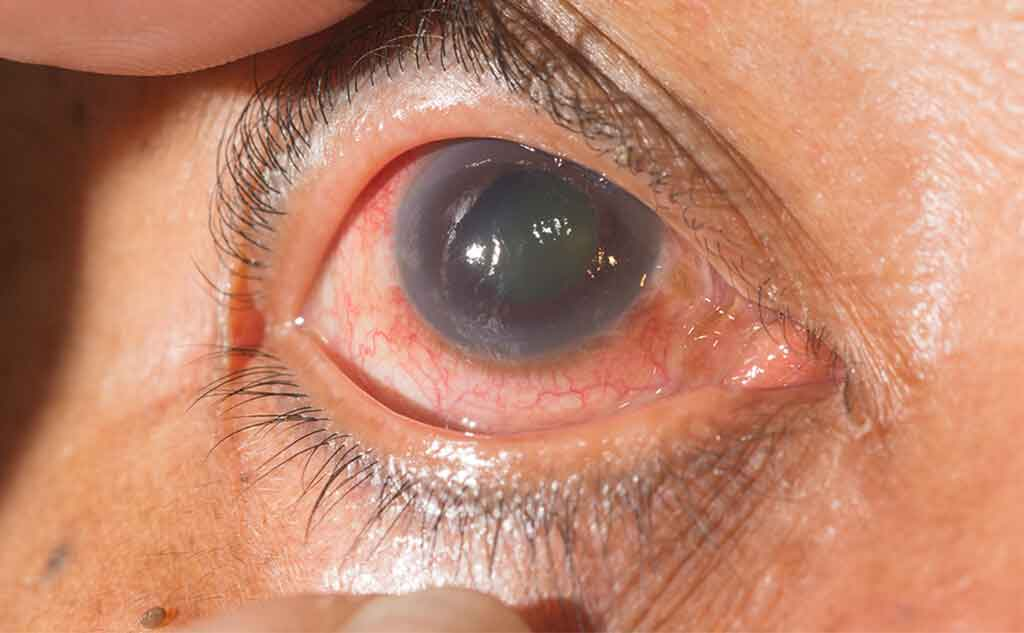

In [1]:
from IPython.display import Image, display

# Display the image
display(Image(filename='glaucoma.jpg'))

## 🎯 Define Obectives

The objective of this project is to analyze glaucoma healthcare data and develop a predictive machine learning model for early glaucoma detection. 

This study aims to:
- Explore and understand the dataset through descriptive analysis  
- Identify significant risk factors associated with glaucoma  
- Apply data preprocessing and feature engineering techniques  
- Build and evaluate classification models  
- Generate actionable clinical insights to support early screening and decision-making

## Import Librairies

In [101]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

## Data Collection

In [102]:
# Load Data
Glaucoma = pd.read_csv('Labels.csv')
# Display Dataset
Glaucoma

,Image Name,Patient,Label,Quality Score,Unnamed: 4
0,0_0.jpg,0,GON+,6.18,NaN
1,1_0.jpg,1,GON+,5.31,NaN
2,1_1.jpg,1,GON+,4.37,NaN
3,2_0.jpg,2,GON+,3.51,NaN
4,2_1.jpg,2,GON+,4.24,NaN
...,...,...,...,...,...
742,286_0.jpg,286,GON-,6.69,NaN
743,286_1.jpg,286,GON-,6.01,NaN
744,287_0.jpg,287,GON-,4.51,NaN
745,287_1.jpg,287,GON-,5.31,NaN


## Data Cleaning and Preparation

In [103]:
# Display the first few rows of the dataset
Glaucoma.head() 

,Image Name,Patient,Label,Quality Score,Unnamed: 4
0,0_0.jpg,0,GON+,6.18,NaN
1,1_0.jpg,1,GON+,5.31,NaN
2,1_1.jpg,1,GON+,4.37,NaN
3,2_0.jpg,2,GON+,3.51,NaN
4,2_1.jpg,2,GON+,4.24,NaN


In [104]:
# Information of Dataset
Glaucoma.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 747 entries, 0 to 746
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Image Name     747 non-null    object 
 1   Patient        747 non-null    int64  
 2   Label          747 non-null    object 
 3   Quality Score  747 non-null    float64
 4   Unnamed: 4     0 non-null      float64
dtypes: float64(2), int64(1), object(2)
memory usage: 29.3+ KB


In [105]:
# Summary statistics using .describe()
Glaucoma.describe(include='all')

,Image Name,Patient,Label,Quality Score,Unnamed: 4
count,747,747.000000,747,747.000000,0.0
unique,747,NaN,2,NaN,NaN
top,0_0.jpg,NaN,GON+,NaN,NaN
freq,1,NaN,548,NaN,NaN
mean,NaN,131.718876,NaN,5.904311,NaN
std,NaN,79.520235,NaN,1.007189,NaN
min,NaN,0.000000,NaN,2.040000,NaN
25%,NaN,63.000000,NaN,5.365000,NaN
50%,NaN,129.000000,NaN,6.180000,NaN
75%,NaN,193.000000,NaN,6.630000,NaN


In [106]:
# Checking if missing data or null values are present in the dataset
Glaucoma.isnull().sum()

Image Name         0
Patient            0
Label              0
Quality Score      0
Unnamed: 4       747
dtype: int64

In [107]:
Glaucoma.columns

Index(['Image Name', 'Patient', 'Label', 'Quality Score', 'Unnamed: 4'], dtype='object')

In [108]:
# Check missing values
print(Glaucoma.isnull().sum())

Image Name         0
Patient            0
Label              0
Quality Score      0
Unnamed: 4       747
dtype: int64


In [109]:
# Convert Quality Score to numeric
Glaucoma['Quality Score'] = pd.to_numeric(Glaucoma['Quality Score'], errors='coerce')

In [110]:
# Remove rows where conversion failed
Glaucoma = Glaucoma.dropna(subset=['Quality Score'])

In [111]:
# Remove useless column
Glaucoma = Glaucoma.drop(columns=['Unnamed: 4'], errors='ignore')

In [112]:
# Convert Quality Score to numeric
Glaucoma['Quality Score'] = pd.to_numeric(Glaucoma['Quality Score'], errors='coerce')

In [113]:
# Check missing values
print(Glaucoma.isnull().sum())

Image Name       0
Patient          0
Label            0
Quality Score    0
dtype: int64


In [114]:
# Fill missing values instead of deleting rows
Glaucoma['Quality Score'] = Glaucoma['Quality Score'].fillna(Glaucoma['Quality Score'].mean())

In [115]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
Glaucoma['Label'] = le.fit_transform(Glaucoma['Label'])

In [116]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

Glaucoma['Quality Score'] = scaler.fit_transform(
    Glaucoma[['Quality Score']]
)

Glaucoma.head()

,Image Name,Patient,Label,Quality Score
0,0_0.jpg,0,0,0.273905
1,1_0.jpg,1,0,-0.590464
2,1_1.jpg,1,0,-1.524380
3,2_0.jpg,2,0,-2.378814
4,2_1.jpg,2,0,-1.653539


## 📓Exploratory Data Analysis (EDA)

In [117]:
# Dataset Shape
Glaucoma.shape

(747, 4)

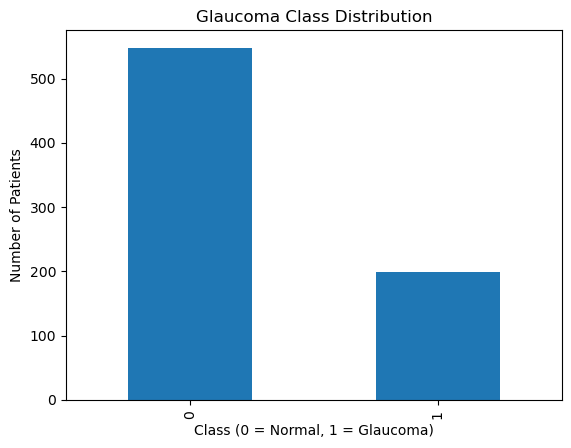

In [118]:
Glaucoma['Label'].value_counts().plot(kind='bar')

plt.title("Glaucoma Class Distribution")
plt.xlabel("Class (0 = Normal, 1 = Glaucoma)")
plt.ylabel("Number of Patients")

plt.show()

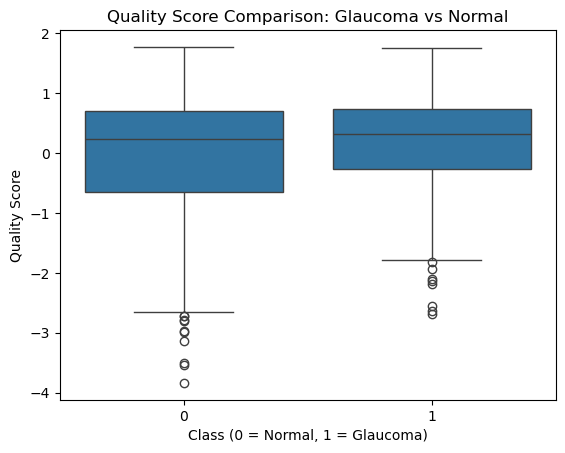

In [127]:
sns.boxplot(x='Label', y='Quality Score', data=Glaucoma)

plt.title("Quality Score Comparison: Glaucoma vs Normal")
plt.xlabel("Class (0 = Normal, 1 = Glaucoma)")
plt.ylabel("Quality Score")

plt.show()

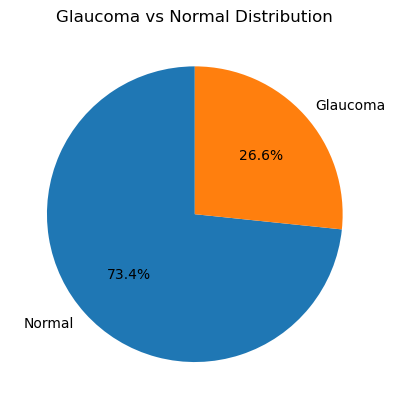

In [128]:
# Pie chart
Glaucoma['Label_text'] = Glaucoma['Label'].replace({0:'Normal', 1:'Glaucoma'}) # Convert labels for visualization


counts = Glaucoma['Label_text'].value_counts() # Count classes


plt.pie(counts, labels=counts.index, autopct='%1.1f%%', startangle=90)

plt.title("Glaucoma vs Normal Distribution")

plt.show()

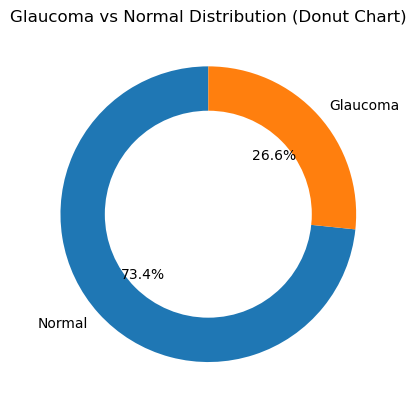

In [129]:

# Pie chart 
Glaucoma['Label_text'] = Glaucoma['Label'].replace({0:'Normal', 1:'Glaucoma'}) # Convert labels to text


counts = Glaucoma['Label_text'].value_counts() # Count classes


fig, ax = plt.subplots() # Create pie chart

ax.pie(counts, labels=counts.index, autopct='%1.1f%%', startangle=90)


centre_circle = plt.Circle((0,0),0.70,fc='white') # Create donut hole
fig.gca().add_artist(centre_circle)

plt.title("Glaucoma vs Normal Distribution (Donut Chart)")

plt.show()

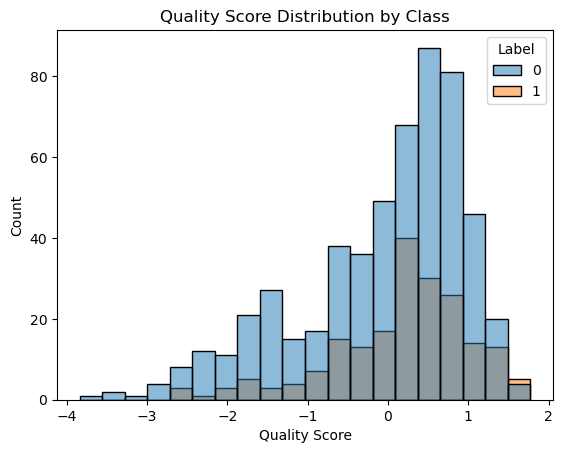

In [119]:
# Quality Score Distribution by Class
sns.histplot(data=Glaucoma, x="Quality Score", hue="Label", bins=20)

plt.title("Quality Score Distribution by Class")
plt.show()

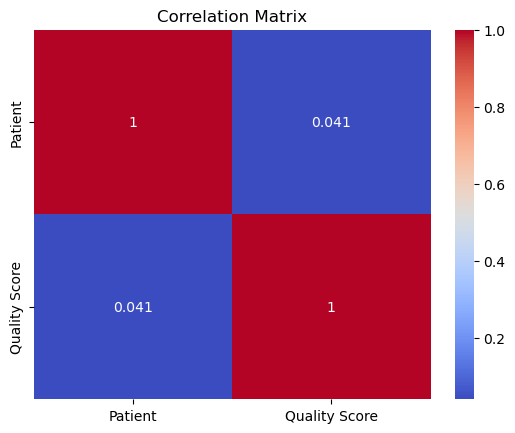

In [120]:
numeric_data = Glaucoma.select_dtypes(include=['int64','float64'])

# Correlation matrix
corr = numeric_data.corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')

plt.title("Correlation Matrix")
plt.show()

In [121]:
# Class Balance Percentage
Glaucoma['Label'].value_counts(normalize=True) * 100

Label
0    73.360107
1    26.639893
Name: proportion, dtype: float64

## Glaucoma WordCloud

In [122]:
!pip install wordcloud

In [125]:
Glaucoma['Label'].value_counts()

Label
0    548
1    199
Name: count, dtype: int64

In [130]:
# Load second dataset
Glaucomadataset = pd.read_csv("glaucoma_dataset.csv")

In [131]:
Glaucomadataset.head()

,Patient ID,Age,Gender,Visual Acuity Measurements,Intraocular Pressure (IOP),Cup-to-Disc Ratio (CDR),Family History,Medical History,Medication Usage,Visual Field Test Results,Optical Coherence Tomography (OCT) Results,Pachymetry,Cataract Status,Angle Closure Status,Visual Symptoms,Diagnosis,Glaucoma Type
0,62431,69,Male,LogMAR 0.1,19.46,0.42,No,Diabetes,"Amoxicillin, Lisinopril, Omeprazole, Atorvasta...","Sensitivity: 0.54, Specificity: 0.75","RNFL Thickness: 86.48 µm, GCC Thickness: 64.14...",541.51,Present,Open,"Tunnel vision, Eye pain, Nausea",No Glaucoma,Primary Open-Angle Glaucoma
1,68125,69,Female,LogMAR 0.1,18.39,0.72,No,Hypertension,"Lisinopril, Amoxicillin, Atorvastatin, Ibuprof...","Sensitivity: 0.72, Specificity: 0.88","RNFL Thickness: 96.88 µm, GCC Thickness: 56.48...",552.77,Absent,Open,"Redness in the eye, Vision loss, Tunnel vision",No Glaucoma,Juvenile Glaucoma
2,63329,67,Female,20/40,23.65,0.72,No,Hypertension,"Amoxicillin, Ibuprofen, Metformin, Atorvastati...","Sensitivity: 0.56, Specificity: 0.8","RNFL Thickness: 89.81 µm, GCC Thickness: 59.05...",573.65,Absent,Closed,"Halos around lights, Vision loss, Redness in t...",No Glaucoma,Juvenile Glaucoma
3,47174,23,Male,LogMAR 0.0,18.04,0.61,No,NaN,"Ibuprofen, Aspirin","Sensitivity: 0.6, Specificity: 0.93","RNFL Thickness: 87.25 µm, GCC Thickness: 63.98...",590.67,Absent,Closed,"Nausea, Nausea, Halos around lights",No Glaucoma,Congenital Glaucoma
4,67361,21,Male,LogMAR 0.1,15.87,0.30,No,Diabetes,"Amoxicillin, Omeprazole, Aspirin, Ibuprofen, A...","Sensitivity: 0.82, Specificity: 0.9","RNFL Thickness: 82.61 µm, GCC Thickness: 66.01...",588.41,Absent,Closed,"Eye pain, Eye pain, Tunnel vision",No Glaucoma,Primary Open-Angle Glaucoma


In [132]:
Glaucomadataset.columns

Index(['Patient ID', 'Age', 'Gender', 'Visual Acuity Measurements',
       'Intraocular Pressure (IOP)', 'Cup-to-Disc Ratio (CDR)',
       'Family History', 'Medical History', 'Medication Usage',
       'Visual Field Test Results',
       'Optical Coherence Tomography (OCT) Results', 'Pachymetry',
       'Cataract Status', 'Angle Closure Status', 'Visual Symptoms',
       'Diagnosis', 'Glaucoma Type'],
      dtype='object')

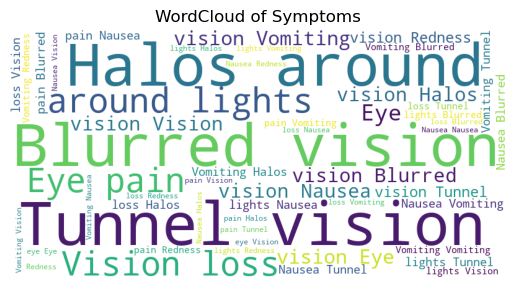

In [134]:

text = " ".join(Glaucomadataset['Visual Symptoms'].dropna().astype(str)) # Convert column to text

wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text) # Create WordCloud

plt.imshow(wordcloud) # Display
plt.axis("off")
plt.title("WordCloud of Symptoms")

plt.show()

## Code for MySQL

In [135]:
!pip install sqlalchemy pymysql pandas

In [ ]:
from sqlalchemy import create_engine
from sqlalchemy import create_engine
from urllib.parse import quote_plus

# MySQL connection
username = "root"
password = quote_plus("Admin@1234")   # encode @, !
host = "localhost"
port = "3306"
database = "Glaucoma"

engine = create_engine(f"mysql+pymysql://{username}:{password}@{host}:{port}/{database}")

# Write DataFrame to MySQL
table_name = "GlaucomaP"
Netflix.to_sql(
    table_name,
    con=engine,
    if_exists="replace",
    index=False
)

# Read back sample
pd.read_sql("SELECT * FROM GlaucomaP LIMIT 5;", engine)